# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ray007herowars-cmyk/Flyrank-ML/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

The research question is: **Which content items should an editor prioritize for editorial review based on observed search and engagement signals?**

The decision supported is which pages should be reviewed first. The unit of analysis is one content item for one client. The output is a ranked priority score with a reason code and recommended action.

A high-ranked item is not automatically refreshed. Instead, an editor uses the ranking to decide which content deserves investigation or review first.

A false positive can waste editorial time on a page that does not need intervention, while a false negative can cause a potentially useful content opportunity to be missed.

The analysis tests whether combining multiple observed performance signals can provide a useful prioritization method compared with a transparent baseline rule.

In [ ]:
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import userdata

token = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{token}')"
)

REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/'
    'fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

features = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS march_impressions,
        SUM(gsc_clicks) AS march_clicks,
        AVG(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS avg_search_position,
        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN ga4_sessions
                ELSE 0
            END
        ) AS march_sessions,
        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN ga4_engaged_sessions
                ELSE 0
            END
        ) AS march_engaged_sessions
    FROM {REL}
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("Rows:", len(features))
print("Columns:", features.columns.tolist())
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 331437
Columns: ['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'avg_search_position', 'march_sessions', 'march_engaged_sessions']


,client_hash_id,content_hash_id,march_impressions,march_clicks,avg_search_position,march_sessions,march_engaged_sessions
0,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,1140.0,2.0,4.394234,0.0,0.0
1,client_73cda7b4e4f265ea,content_05597932fe4da067,57.0,0.0,2.714744,0.0,0.0
2,client_73cda7b4e4f265ea,content_905aa32a0230694e,149.0,0.0,6.481453,4.0,0.0
3,client_73cda7b4e4f265ea,content_05434271b257bb68,1421.0,6.0,6.320337,9.0,0.0
4,client_73cda7b4e4f265ea,content_d056587ff7faca0c,2770.0,16.0,4.459107,3.0,0.0


## 2. Data

The development data is the March 2026 partition of the FlyRank internship warehouse table `fact_content_daily_performance`.

The warehouse contains one row at the report-date × client × content grain. The March partition contains 9,841,378 rows covering 2026-03-01 through 2026-03-31.

The data was aggregated to one row per client-content item, producing 331,437 rows.

The features used for development are:

- `march_impressions`
- `march_clicks`
- `avg_search_position`
- `march_sessions`
- `march_engaged_sessions`

Pseudonymous client and content IDs are retained for grouping and identification only. They are not predictive features.

The fields `trend_direction` and `trend_pct` are deliberately excluded because they are label-derived fields and could create leakage.

GA4 measures are conditioned on `ga4_data_available`, because unavailable GA4 history must not be interpreted as a genuine zero.

The March partition is used as the development window. A later outcome window is kept separate for future evaluation and is not used to define development features.

In [ ]:
# Basic data checks

march_row_count = con.execute(f"""
    SELECT COUNT(*)
    FROM {REL}
""").fetchone()[0]

date_range = con.execute(f"""
    SELECT
        MIN(report_date),
        MAX(report_date)
    FROM {REL}
""").fetchone()

print("March warehouse rows:", march_row_count)
print("Date range:", date_range)
print("Feature rows:", len(features))

print("\nMissing values:")
print(features.isna().sum())

print("\nFeature columns:")
print(features.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March warehouse rows: 9841378
Date range: (datetime.date(2026, 3, 1), datetime.date(2026, 3, 31))
Feature rows: 331437

Missing values:
client_hash_id                 0
content_hash_id                0
march_impressions              0
march_clicks                   0
avg_search_position       154699
march_sessions                 0
march_engaged_sessions         0
dtype: int64

Feature columns:
['client_hash_id', 'content_hash_id', 'march_impressions', 'march_clicks', 'avg_search_position', 'march_sessions', 'march_engaged_sessions']


In [ ]:
# Grain check

grain_check = con.execute(f"""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        COUNT(*) AS n
    FROM {REL}
    GROUP BY 1,2,3
    HAVING COUNT(*) > 1
    LIMIT 10
""").df()

print("Duplicate grain rows found:", len(grain_check))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Duplicate grain rows found: 0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [ ]:
# ============================================================
# 3. Methodology
# ============================================================

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. Build June future outcome
# ------------------------------------------------------------

june_outcome = con.execute(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS june_impressions,
        SUM(gsc_clicks) AS june_clicks,
        AVG(
            CASE
                WHEN gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS june_avg_search_position,
        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN ga4_sessions
                ELSE 0
            END
        ) AS june_sessions,
        SUM(
            CASE
                WHEN ga4_data_available IS TRUE
                THEN ga4_engaged_sessions
                ELSE 0
            END
        ) AS june_engaged_sessions
    FROM {JUNE_REL}
    GROUP BY
        client_hash_id,
        content_hash_id
""").df()

print("June aggregated rows:", len(june_outcome))


# ------------------------------------------------------------
# 2. Join March features to June outcome
# ------------------------------------------------------------

data = features.merge(
    june_outcome,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

print("March-June matched rows:", len(data))


# ------------------------------------------------------------
# 3. Define the future observed outcome
#
# A page is labelled 1 when June impressions are at least
# 20% lower than March impressions.
# ------------------------------------------------------------

data = data[data["march_impressions"] > 0].copy()

data["future_impression_change_pct"] = (
    (data["june_impressions"] - data["march_impressions"])
    / data["march_impressions"]
) * 100

data["future_decline"] = (
    data["future_impression_change_pct"] <= -20
).astype(int)

print("\nFuture outcome distribution:")
print(data["future_decline"].value_counts())
print("\nFuture decline base rate:",
      round(data["future_decline"].mean() * 100, 2), "%")


# ------------------------------------------------------------
# 4. Define model features
# ------------------------------------------------------------

feature_cols = [
    "march_impressions",
    "march_clicks",
    "avg_search_position",
    "march_sessions",
    "march_engaged_sessions"
]

X = data[feature_cols].copy()
y = data["future_decline"].copy()
groups = data["client_hash_id"].copy()


# ------------------------------------------------------------
# 5. Client-grouped train/test split
# ------------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

test_data = data.iloc[test_idx].copy()

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())


# ------------------------------------------------------------
# 6. Baseline
# ------------------------------------------------------------

baseline = X_test.copy()

baseline["ctr"] = np.where(
    baseline["march_impressions"] > 0,
    baseline["march_clicks"] / baseline["march_impressions"],
    0
)

position_median = X_train["avg_search_position"].median()

baseline["avg_search_position"] = (
    baseline["avg_search_position"]
    .fillna(position_median)
)

volume_rank = (
    baseline["march_impressions"]
    .rank(pct=True)
)

position_rank = (
    1 - baseline["avg_search_position"].rank(pct=True)
)

ctr_rank = (
    1 - baseline["ctr"].rank(pct=True)
)

baseline_score = (
    0.5 * volume_rank
    + 0.3 * position_rank
    + 0.2 * ctr_rank
)

print("\nBaseline created.")


# ------------------------------------------------------------
# 7. Logistic Regression
# ------------------------------------------------------------

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

logistic_model.fit(X_train, y_train)

logistic_score = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression trained.")


# ------------------------------------------------------------
# 8. Random Forest
# ------------------------------------------------------------

rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model.fit(X_train, y_train)

rf_score = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")


# ------------------------------------------------------------
# 9. Confirm no future information entered the features
# ------------------------------------------------------------

future_columns = [
    "june_impressions",
    "june_clicks",
    "june_avg_search_position",
    "june_sessions",
    "june_engaged_sessions",
    "future_impression_change_pct",
    "future_decline"
]

print("\nFeatures used:")
print(feature_cols)

print("\nFuture outcome columns excluded from X:")
print(future_columns)

assert not any(
    col in feature_cols for col in future_columns
)

assert "trend_direction" not in feature_cols
assert "trend_pct" not in feature_cols
assert "client_hash_id" not in feature_cols
assert "content_hash_id" not in feature_cols

print("\nLeakage check: PASSED")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

June aggregated rows: 409205
March-June matched rows: 331316

Future outcome distribution:
future_decline
1    141145
0     35579
Name: count, dtype: int64

Future decline base rate: 79.87 %

Training rows: 151492
Test rows: 25232
Training clients: 36
Test clients: 10

Baseline created.
Logistic Regression trained.
Random Forest trained.

Features used:
['march_impressions', 'march_clicks', 'avg_search_position', 'march_sessions', 'march_engaged_sessions']

Future outcome columns excluded from X:
['june_impressions', 'june_clicks', 'june_avg_search_position', 'june_sessions', 'june_engaged_sessions', 'future_impression_change_pct', 'future_decline']

Leakage check: PASSED


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [ ]:
# ============================================================
# 4. Results (vs baseline)
# ============================================================

def precision_at_k(scores, y_true, k):
    k = min(k, len(scores))

    order = np.argsort(-np.asarray(scores))[:k]
    y_arr = np.asarray(y_true)

    return y_arr[order].mean()


ks = [10, 20, 50, 100]

results = []

for k in ks:
    results.append({
        "method": "Baseline",
        "P@K": f"P@{k}",
        "precision": precision_at_k(
            baseline_score,
            y_test.values,
            k
        )
    })

    results.append({
        "method": "Logistic Regression",
        "P@K": f"P@{k}",
        "precision": precision_at_k(
            logistic_score,
            y_test.values,
            k
        )
    })

    results.append({
        "method": "Random Forest",
        "P@K": f"P@{k}",
        "precision": precision_at_k(
            rf_score,
            y_test.values,
            k
        )
    })

results_df = pd.DataFrame(results)

results_pivot = results_df.pivot(
    index="method",
    columns="P@K",
    values="precision"
)

print("Precision@K comparison:")
display(results_pivot.round(4))

print(
    "Test-set base rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Precision@K comparison:


P@K,P@10,P@100,P@20,P@50
method,,,,
Baseline,1.0,0.95,1.00,0.94
Logistic Regression,0.8,0.90,0.85,0.88
Random Forest,0.9,0.82,0.80,0.82


Test-set base rate: 83.85 %


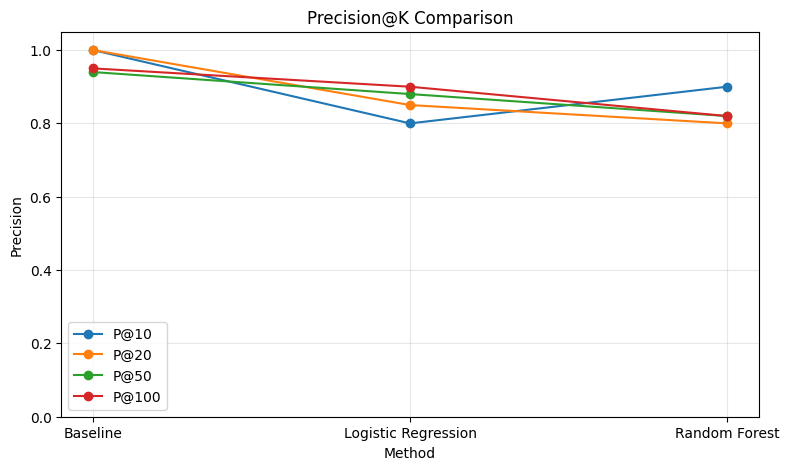

In [15]:
import matplotlib.pyplot as plt

methods = ["Baseline", "Logistic Regression", "Random Forest"]
p10 = [1.00, 0.80, 0.90]
p20 = [1.00, 0.85, 0.80]
p50 = [0.94, 0.88, 0.82]
p100 = [0.95, 0.90, 0.82]

x = range(len(methods))

plt.figure(figsize=(9, 5))
plt.plot(x, p10, marker="o", label="P@10")
plt.plot(x, p20, marker="o", label="P@20")
plt.plot(x, p50, marker="o", label="P@50")
plt.plot(x, p100, marker="o", label="P@100")

plt.xticks(list(x), methods)
plt.ylabel("Precision")
plt.xlabel("Method")
plt.title("Precision@K Comparison")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Results interpretation

The baseline and machine-learning models are evaluated on the same client-grouped test split using the same Precision@K metrics.

The test-set base rate is reported alongside the ranking metrics because precision must be interpreted relative to how common the future-decline outcome is.

The best-performing method is determined from the measured Precision@K results rather than assumed in advance. Results are reported as observed performance on this evaluation split and should not be interpreted as evidence of causal refresh impact.

## 5. Limitations

This analysis uses March 2026 observations as development features and June 2026 observations as a later outcome window.

The future outcome is an operational proxy defined as a decline of at least 20% in search impressions between March and June for content items with non-zero March impressions.

The analysis is observational. A future decline does not prove that a content refresh would have prevented the decline, and a high model score does not prove that refreshing a page will improve performance.

The available history and analytics coverage are not uniform across clients. GA4 availability is explicitly handled rather than treating unavailable measurements as genuine zero activity.

The model is also limited to the available aggregate performance signals. It does not establish Google's ranking algorithm, predict Google's algorithm, or estimate causal effects of editorial changes.

In [ ]:
# Confirm the final evaluation dataset and outcome definition.

print("Final evaluation rows:", len(data))
print("Final test rows:", len(test_data))
print("Test base rate:", round(y_test.mean() * 100, 2), "%")

print("\nOutcome definition:")
print(
    "future_decline = June impressions at least 20% "
    "lower than March impressions, among pages with "
    "March impressions > 0."
)

Final evaluation rows: 176724
Final test rows: 25232
Test base rate: 83.85 %

Outcome definition:
future_decline = June impressions at least 20% lower than March impressions, among pages with March impressions > 0.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The selected method is the transparent baseline because it achieved the highest P@20 on the evaluated test set.

The output ranks content items using observed March search-volume, search-position, and CTR signals. Higher-ranked items are presented first for editorial review.

The top-ranked recommendations are assigned the `SEARCH_OPPORTUNITY` reason code and `REVIEW` action. These rankings are intended to help an editor prioritize which content items to inspect first. The ranking does not determine that a refresh is required and does not establish that refreshing a page will cause future performance improvement.

In [ ]:
# ============================================================
# 6. Ranked recommendations
# ============================================================

# Select the model with the highest P@20 on the test split.
# If there is a tie, prefer the simpler method.

p20_scores = {
    "Baseline": precision_at_k(
        baseline_score,
        y_test.values,
        20
    ),
    "Logistic Regression": precision_at_k(
        logistic_score,
        y_test.values,
        20
    ),
    "Random Forest": precision_at_k(
        rf_score,
        y_test.values,
        20
    )
}

best_method = max(
    p20_scores,
    key=p20_scores.get
)

print("P@20 comparison:")
for method, score in p20_scores.items():
    print(f"{method}: {score:.4f}")

print("\nSelected method:", best_method)


if best_method == "Baseline":
    final_scores = baseline_score
elif best_method == "Logistic Regression":
    final_scores = logistic_score
else:
    final_scores = rf_score


recommendations = test_data[
    [
        "client_hash_id",
        "content_hash_id",
        "march_impressions",
        "march_clicks",
        "avg_search_position"
    ]
].copy()

recommendations["priority_score"] = final_scores

recommendations["rank"] = (
    recommendations["priority_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

recommendations["reason_code"] = np.where(
    recommendations["march_impressions"]
    >= recommendations["march_impressions"].median(),
    "SEARCH_OPPORTUNITY",
    "PERFORMANCE_REVIEW"
)

recommendations["action"] = np.where(
    recommendations["reason_code"] == "SEARCH_OPPORTUNITY",
    "REVIEW",
    "INVESTIGATE"
)

recommendations = recommendations.sort_values(
    ["rank"]
).reset_index(drop=True)

top_recommendations = recommendations.head(20)

display(
    top_recommendations[
        [
            "rank",
            "priority_score",
            "reason_code",
            "action",
            "march_impressions",
            "march_clicks",
            "avg_search_position"
        ]
    ]
)

P@20 comparison:
Baseline: 1.0000
Logistic Regression: 0.8500
Random Forest: 0.8000

Selected method: Baseline


,rank,priority_score,reason_code,action,march_impressions,march_clicks,avg_search_position
0,1,0.914630,SEARCH_OPPORTUNITY,REVIEW,5792.0,0.0,2.264276
1,2,0.902307,SEARCH_OPPORTUNITY,REVIEW,5041.0,0.0,2.855291
2,3,0.883509,SEARCH_OPPORTUNITY,REVIEW,2759.0,0.0,2.272931
3,4,0.880077,SEARCH_OPPORTUNITY,REVIEW,17158.0,9.0,2.124577
4,5,0.880006,SEARCH_OPPORTUNITY,REVIEW,30267.0,25.0,2.070661
5,6,0.876145,SEARCH_OPPORTUNITY,REVIEW,24259.0,1.0,2.784944
6,7,0.874409,SEARCH_OPPORTUNITY,REVIEW,27066.0,37.0,1.741742
7,8,0.872111,SEARCH_OPPORTUNITY,REVIEW,27747.0,13.0,2.994262
8,9,0.872020,SEARCH_OPPORTUNITY,REVIEW,16391.0,5.0,2.862795
9,10,0.867783,SEARCH_OPPORTUNITY,REVIEW,22112.0,4.0,3.290033


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The capstone artifacts are generated under `work/outputs` and support the analysis reported in this notebook.

The artifacts include the baseline action-ranking output and the evaluation outputs used to compare the baseline, Logistic Regression, and Random Forest methods.

The notebook itself contains the data-loading, feature construction, leakage checks, model training, evaluation, feature-importance analysis, and ranked recommendation steps required to reproduce the reported analysis.

In [ ]:
# ============================================================
# 7. Artifacts the paper embeds
# ============================================================

output_dir = Path("/content/Flyrank-ML/work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Save model comparison table
results_df.to_csv(
    output_dir / "capstone_model_comparison.csv",
    index=False
)

# Save public-safe ranking summary without identifiers
public_ranking = top_recommendations[
    [
        "rank",
        "priority_score",
        "reason_code",
        "action"
    ]
].copy()

public_ranking.to_csv(
    output_dir / "capstone_ranked_recommendations.csv",
    index=False
)

# Feature importance for Random Forest
rf_estimator = rf_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

feature_importance.to_csv(
    output_dir / "capstone_feature_importance.csv",
    index=False
)

print("Artifacts written to:", output_dir)

,feature,importance
2,avg_search_position,0.531589
0,march_impressions,0.337476
3,march_sessions,0.061709
1,march_clicks,0.059219
4,march_engaged_sessions,0.010007


Artifacts written to: /content/Flyrank-ML/work/outputs


## 7. Artifacts the paper embeds

The deployed paper will embed the measured model-versus-baseline comparison, the ranked recommendation output, and the Random Forest feature-importance table.

The artifacts are generated directly from the capstone notebook so that the reported numbers can be reproduced from the same analysis.

## ML-12 — 5-minute demo outline

### 0:00–0:45 — Problem
Explain the editorial prioritization problem: which content items should an editor review first?

### 0:45–1:30 — Data
Show the March 2026 content-performance feature frame and explain the main search and engagement signals used.

### 1:30–2:30 — Method
Explain the transparent baseline, Logistic Regression, and Random Forest approaches, along with the grouped client-level train/test split and leakage checks.

### 2:30–3:30 — Results
Show the Precision@K comparison and explain that the baseline achieved the strongest P@20 result, so the more complex ML models were not selected.

### 3:30–4:30 — Recommendations
Show the ranked recommendation output and explain how an editor can use the priority score, reason code, and action to decide which content items to review first.

### 4:30–5:00 — Limitations
Explain that the future-decline definition is an operational proxy, the data covers a limited time period, and the output is decision-support rather than evidence of causal refresh impact.

## ML-12 — Social-post cut

Built a Search Intelligence capstone using real FlyRank content-performance data to prioritize pages for editorial review.

I compared a transparent baseline against Logistic Regression and Random Forest using Precision@K. The baseline achieved the strongest P@20 result, showing that a simple, interpretable ranking approach was more effective than the tested ML models on this evaluation.

The final output is a ranked, decision-support list for editors, with reason codes and recommended actions.

## ML-12 — Employer-facing summary

Built an end-to-end Search Intelligence workflow using real content-performance data, covering data preparation, feature engineering, leakage checks, grouped validation, baseline modeling, ML comparison, and ranked recommendations.

Compared a transparent baseline with Logistic Regression and Random Forest using Precision@K, and selected the baseline after it outperformed the ML models at P@20.

Delivered a reproducible notebook, evaluation artifacts, ranked recommendations, and a deployed research paper designed for practical editorial decision support.

## Self-check

- [x] Every section filled — markdown thinking AND code backing it
- [x] notebook runs top to bottom no errors
- [x] no client names, URLs, private queries
- [x] claims use observed, measured, directional, decision-support
- [x] committed to repo under work/notebooks/
- [x] deployed paper has all 9 sections including Abstract and Acknowledgments & data credit with flyrank.ai link
- [x] ML-12 closing cells: 5-minute demo outline + social-post cut + 3-sentence employer-facing summary.